# results: zero-shot vs fine-tuning
- year vs accuracy for zero-shot and fine-tune
- year vs fairness for zero-shot and fine-tune
- paried before/after comparisons for each model
- delta plots: how much each model changed after fine-tuning
- movement in accuracy-fairness space
- group-level changes in accuracy, fp rate, fn rate

OBS. only 3 models, so the year trends are mostly descriptive, not something to be interpretated strongly, but
- whether fine-tuning improves accuracy
- whether it improves fairness
- whether there is an accuracy-fairness trade-off
- which identity groups that drive the fairness changes

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

In [2]:
OUT_DIR = "results_civilcomments_zeroshot_vs_ft"
SUMMARY_CSV = os.path.join(OUT_DIR, "before_after_summary.csv")
GROUPS_CSV = os.path.join(OUT_DIR, "before_after_groups.csv")

if not os.path.exists(SUMMARY_CSV):
    raise FileNotFoundError(
        f"Could not find {SUMMARY_CSV}. Run fine_tuning.ipynb first so the before/after results are saved."
    )

if not os.path.exists(GROUPS_CSV):
    raise FileNotFoundError(
        f"Could not find {GROUPS_CSV}. Run fine_tuning.ipynb first so the group-level results are saved."
    )

df_summary = pd.read_csv(SUMMARY_CSV).sort_values(["year", "model_id"]).reset_index(drop=True)
df_groups = pd.read_csv(GROUPS_CSV).sort_values(["year", "model_id", "stage", "group"]).reset_index(drop=True)

df_summary

,year,model_id,short_name,adapter_dir,zero_shot_test_acc,zero_shot_avg_minmax_abs,zero_shot_test_fpr,zero_shot_test_fnr,ft_test_acc,ft_avg_minmax_abs,ft_test_fpr,ft_test_fnr,delta_acc,delta_fairness
0,2021,EleutherAI/gpt-neo-2.7B,gpt-neo-2.7B,results_civilcomments_zeroshot_vs_ft\adapter_2...,0.790,0.171684,0.109215,0.942149,0.792,0.283537,0.109215,0.925620,0.002,0.111853
1,2023,mistralai/Mistral-7B-v0.1,Mistral-7B,results_civilcomments_zeroshot_vs_ft\adapter_2...,0.794,0.278356,0.120592,0.826446,0.875,0.350226,0.072810,0.504132,0.081,0.071869
2,2024,Qwen/Qwen2.5-7B,Qwen2.5-7B,results_civilcomments_zeroshot_vs_ft\adapter_2...,0.833,0.162382,0.094425,0.694215,0.860,0.194060,0.086462,0.528926,0.027,0.031679


In [3]:
# reshape to long format
FAIR_COL = "avg_minmax_abs"

long_rows = []
for _, row in df_summary.iterrows():
    long_rows.append({
        "year": int(row["year"]),
        "model_id": row["model_id"],
        "short_name": row["short_name"],
        "stage": "zero_shot",
        "test_acc": row["zero_shot_test_acc"],
        FAIR_COL: row["zero_shot_avg_minmax_abs"],
        "test_fpr": row["zero_shot_test_fpr"],
        "test_fnr": row["zero_shot_test_fnr"],
    })
    long_rows.append({
        "year": int(row["year"]),
        "model_id": row["model_id"],
        "short_name": row["short_name"],
        "stage": "fine_tuned",
        "test_acc": row["ft_test_acc"],
        FAIR_COL: row["ft_avg_minmax_abs"],
        "test_fpr": row["ft_test_fpr"],
        "test_fnr": row["ft_test_fnr"],
    })

df_long = pd.DataFrame(long_rows).sort_values(["year", "model_id", "stage"]).reset_index(drop=True)
df_long

,year,model_id,short_name,stage,test_acc,avg_minmax_abs,test_fpr,test_fnr
0,2021,EleutherAI/gpt-neo-2.7B,gpt-neo-2.7B,fine_tuned,0.792,0.283537,0.109215,0.925620
1,2021,EleutherAI/gpt-neo-2.7B,gpt-neo-2.7B,zero_shot,0.790,0.171684,0.109215,0.942149
2,2023,mistralai/Mistral-7B-v0.1,Mistral-7B,fine_tuned,0.875,0.350226,0.072810,0.504132
3,2023,mistralai/Mistral-7B-v0.1,Mistral-7B,zero_shot,0.794,0.278356,0.120592,0.826446
4,2024,Qwen/Qwen2.5-7B,Qwen2.5-7B,fine_tuned,0.860,0.194060,0.086462,0.528926
5,2024,Qwen/Qwen2.5-7B,Qwen2.5-7B,zero_shot,0.833,0.162382,0.094425,0.694215


In [4]:
# result table
summary_tbl = df_summary[[
    "year", "short_name",
    "zero_shot_test_acc", "ft_test_acc", "delta_acc",
    "zero_shot_avg_minmax_abs", "ft_avg_minmax_abs", "delta_fairness",
    "zero_shot_test_fpr", "ft_test_fpr",
    "zero_shot_test_fnr", "ft_test_fnr",
]].copy()

summary_tbl.round(4)

,year,short_name,zero_shot_test_acc,ft_test_acc,delta_acc,zero_shot_avg_minmax_abs,ft_avg_minmax_abs,delta_fairness,zero_shot_test_fpr,ft_test_fpr,zero_shot_test_fnr,ft_test_fnr
0,2021,gpt-neo-2.7B,0.790,0.792,0.002,0.1717,0.2835,0.1119,0.1092,0.1092,0.9421,0.9256
1,2023,Mistral-7B,0.794,0.875,0.081,0.2784,0.3502,0.0719,0.1206,0.0728,0.8264,0.5041
2,2024,Qwen2.5-7B,0.833,0.860,0.027,0.1624,0.1941,0.0317,0.0944,0.0865,0.6942,0.5289


In [5]:
print("Mean delta accuracy:", round(df_summary["delta_acc"].mean(), 4))
print("Mean delta fairness gap:", round(df_summary["delta_fairness"].mean(), 4))
print("Note: lower fairness gap is better, so negative delta_fairness means improvement.")

Mean delta accuracy: 0.0367
Mean delta fairness gap: 0.0718
Note: lower fairness gap is better, so negative delta_fairness means improvement.


### year vs accuracy and year vs fairness

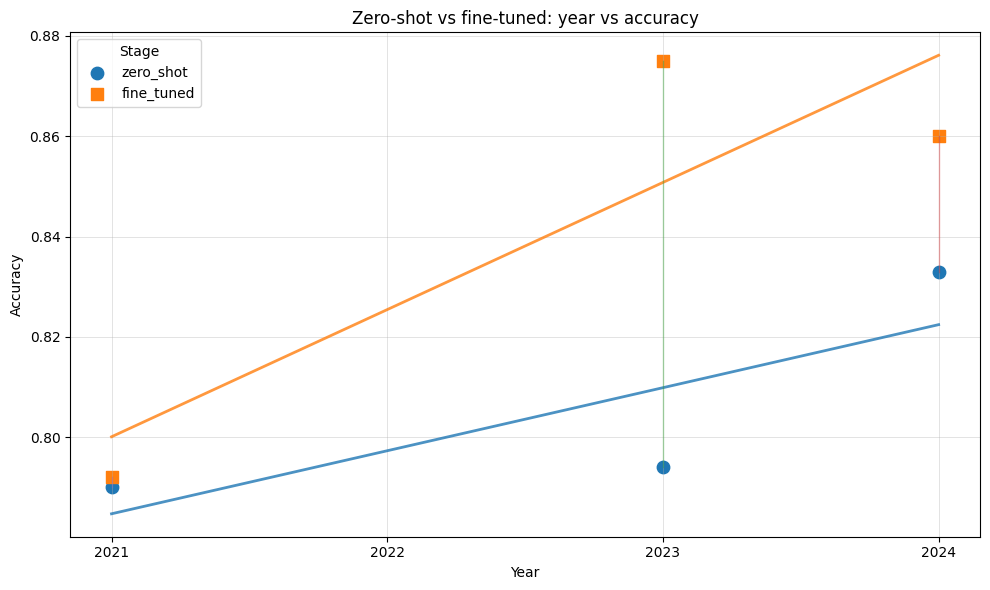

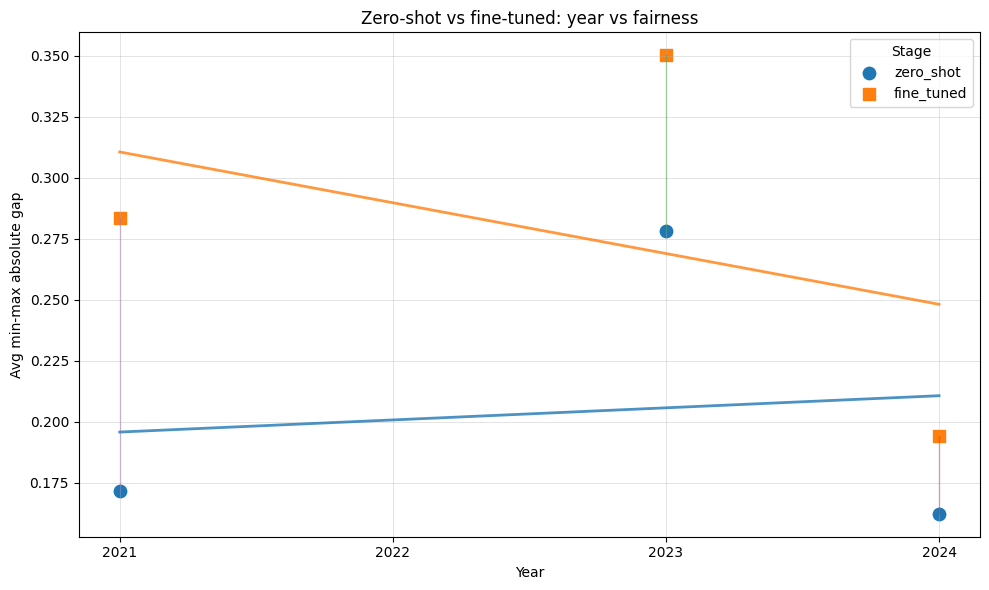

In [6]:
def scatter_stage_by_year(df, ycol, ylabel, title):
    fig, ax = plt.subplots(figsize=(10, 6))

    markers = {"zero_shot": "o", "fine_tuned": "s"}

    for stage in ["zero_shot", "fine_tuned"]:
        sub = df[df["stage"] == stage].copy()
        ax.scatter(sub["year"], sub[ycol], marker=markers[stage], s=80, label=stage)

        if len(sub) >= 2:
            z = np.polyfit(sub["year"], sub[ycol], 1)
            x_line = np.linspace(sub["year"].min(), sub["year"].max(), 100)
            y_line = np.polyval(z, x_line)
            ax.plot(x_line, y_line, linewidth=2, alpha=0.8)

    for _, sub in df.groupby("short_name"):
        ax.plot(sub["year"], sub[ycol], linewidth=1, alpha=0.4)

    ax.set_title(title)
    ax.set_xlabel("Year")
    ax.set_ylabel(ylabel)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.grid(True, linewidth=0.5, alpha=0.5)
    ax.legend(title="Stage")
    plt.tight_layout()
    plt.show()

scatter_stage_by_year(df_long, "test_acc", "Accuracy", "Zero-shot vs fine-tuned: year vs accuracy")
scatter_stage_by_year(df_long, FAIR_COL, "Avg min-max absolute gap", "Zero-shot vs fine-tuned: year vs fairness")

### paired before/after plots


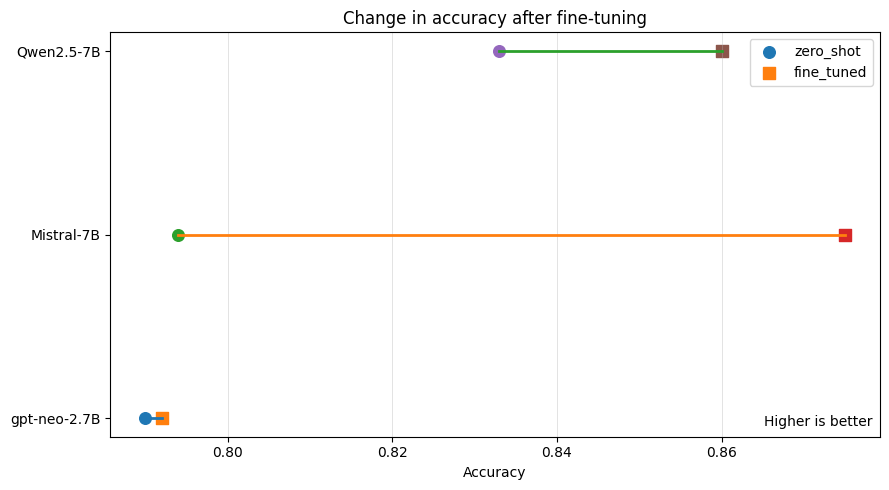

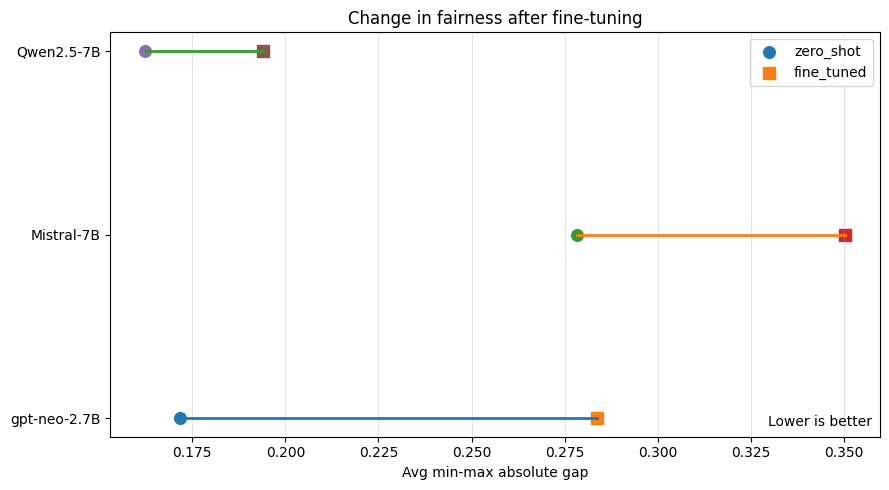

In [7]:
def dumbbell_plot(df, before_col, after_col, ylabel, title, lower_is_better=False):
    order = df.sort_values("year")["short_name"].tolist()
    plot_df = df.set_index("short_name").loc[order].reset_index()

    fig, ax = plt.subplots(figsize=(9, 5))
    y = np.arange(len(plot_df))

    for i, row in plot_df.iterrows():
        ax.plot([row[before_col], row[after_col]], [i, i], linewidth=2)
        ax.scatter(row[before_col], i, s=70, marker="o", label="zero_shot" if i == 0 else None)
        ax.scatter(row[after_col], i, s=70, marker="s", label="fine_tuned" if i == 0 else None)

    ax.set_yticks(y)
    ax.set_yticklabels(plot_df["short_name"])
    ax.set_xlabel(ylabel)
    ax.set_title(title)
    ax.grid(True, axis="x", linewidth=0.5, alpha=0.5)
    ax.legend()

    if lower_is_better:
        ax.text(0.99, 0.02, "Lower is better", transform=ax.transAxes, ha="right", va="bottom")
    else:
        ax.text(0.99, 0.02, "Higher is better", transform=ax.transAxes, ha="right", va="bottom")

    plt.tight_layout()
    plt.show()

dumbbell_plot(
    df_summary,
    "zero_shot_test_acc",
    "ft_test_acc",
    "Accuracy",
    "Change in accuracy after fine-tuning",
    lower_is_better=False,
)

dumbbell_plot(
    df_summary,
    "zero_shot_avg_minmax_abs",
    "ft_avg_minmax_abs",
    "Avg min-max absolute gap",
    "Change in fairness after fine-tuning",
    lower_is_better=True,
)

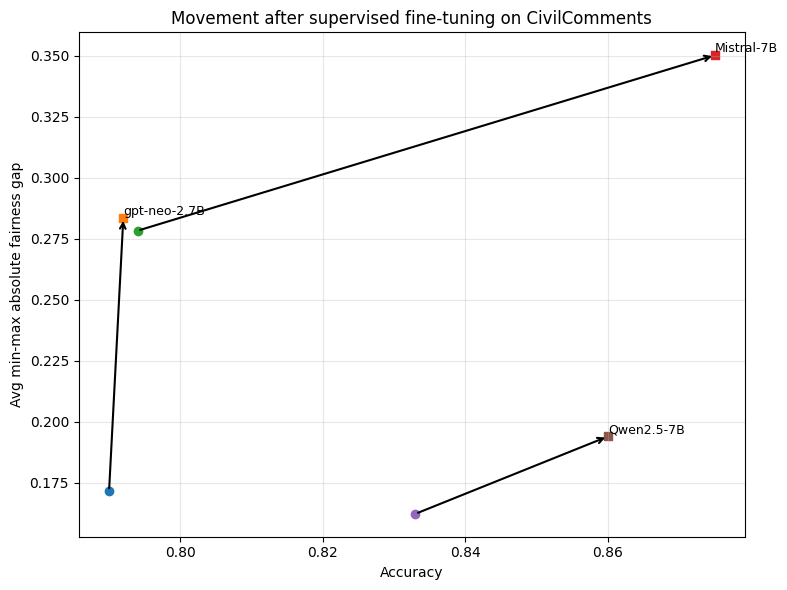

In [8]:
def plot_before_after_arrows(df):
    plt.figure(figsize=(8, 6))

    for _, row in df.iterrows():
        x0 = row["zero_shot_test_acc"]
        y0 = row["zero_shot_avg_minmax_abs"]
        x1 = row["ft_test_acc"]
        y1 = row["ft_avg_minmax_abs"]

        plt.scatter(x0, y0, marker="o")
        plt.scatter(x1, y1, marker="s")

        plt.annotate(
            "",
            xy=(x1, y1),
            xytext=(x0, y0),
            arrowprops=dict(arrowstyle="->", lw=1.5)
        )

        plt.text(x1, y1, row["short_name"], fontsize=9, ha="left", va="bottom")

    plt.xlabel("Accuracy")
    plt.ylabel("Avg min-max absolute fairness gap")
    plt.title("Movement after supervised fine-tuning on CivilComments")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_before_after_arrows(df_summary)

### Delta plots
These make it easy to see whether fine-tuning helps or hurts each metric.

Interpretation:
- positive `delta_acc` means accuracy improved
- negative `delta_fairness` means fairness improved, because the gap became smaller

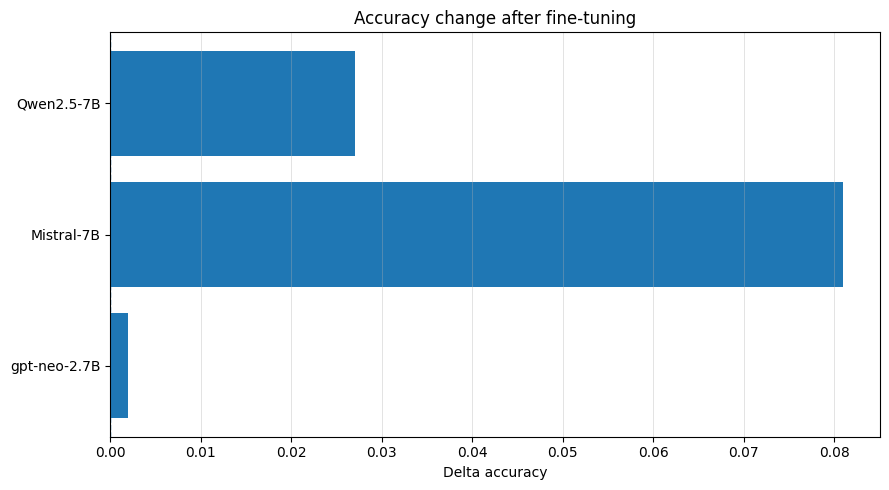

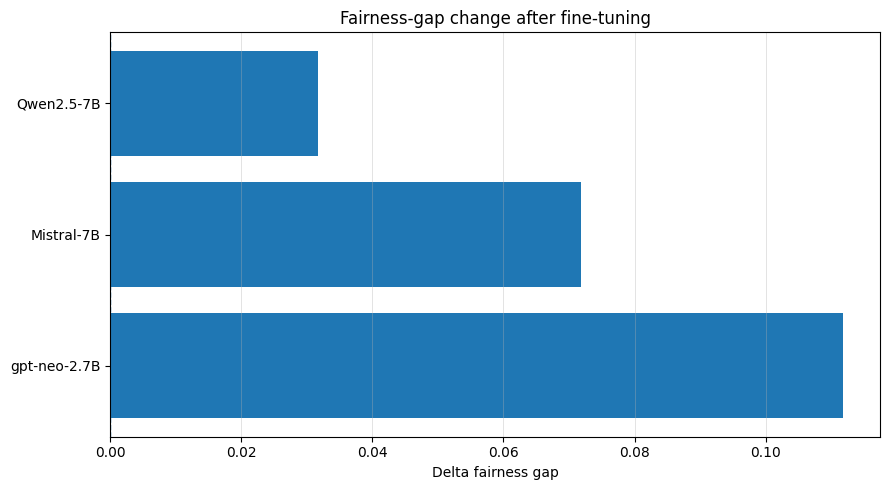

In [9]:
def plot_delta_by_model(df, delta_col, xlabel, title, zero_line=0):
    order = df.sort_values("year")["short_name"].tolist()
    plot_df = df.set_index("short_name").loc[order].reset_index()

    fig, ax = plt.subplots(figsize=(9, 5))
    y = np.arange(len(plot_df))
    ax.barh(y, plot_df[delta_col])
    ax.axvline(zero_line, linestyle="--", linewidth=1)
    ax.set_yticks(y)
    ax.set_yticklabels(plot_df["short_name"])
    ax.set_xlabel(xlabel)
    ax.set_title(title)
    ax.grid(True, axis="x", linewidth=0.5, alpha=0.5)
    plt.tight_layout()
    plt.show()

plot_delta_by_model(df_summary, "delta_acc", "Delta accuracy", "Accuracy change after fine-tuning")
plot_delta_by_model(df_summary, "delta_fairness", "Delta fairness gap", "Fairness-gap change after fine-tuning")

### group-level changes

In [10]:
metrics = ["acc", "pos_rate", "fpr", "fnr"]

# pivot zero-shot and fine-tuned side by side
wide = (
    df_groups
    .pivot_table(
        index=["year", "model_id", "short_name", "group"],
        columns="stage",
        values=metrics,
        aggfunc="first"
    )
)

wide.columns = [f"{metric}_{stage}" for metric, stage in wide.columns]
wide = wide.reset_index()

for metric in metrics:
    wide[f"delta_{metric}"] = wide[f"{metric}_fine_tuned"] - wide[f"{metric}_zero_shot"]

wide.head()

KeyError: 'short_name'